# Decorrelation Measurements with multiple pixels
* Exponential decorrelation time $\tau_c = 107 \mu s$
* Integration time $10^{16}$ exposures


Paper: Masive Parallel real time multispeckle diffuse correlation spectroscopy with 250,000 SPADs
* Diffuse Correlation Spectroscopy (DCR) can reconstruct temporal dynamics of speckle field at time scales decorrelation time. 
* Slow Flow: The speckles drift very slowly. If the pixel is bright at $t=0$, it will probably still be bright at $t=100 \ \mu s$. The correlation lasts a long time, resulting in a wide, slow exponential drop (a long decorrelation time, $\tau_c$).Fast Flow: The speckles whip past the pixel rapidly. A bright spot at $t=0$ will be completely gone by $t=10 \ \mu s$. The pixel quickly loses memory of its initial state, resulting in a steep, fast exponential drop (a short $\tau_c$).

## Calibration

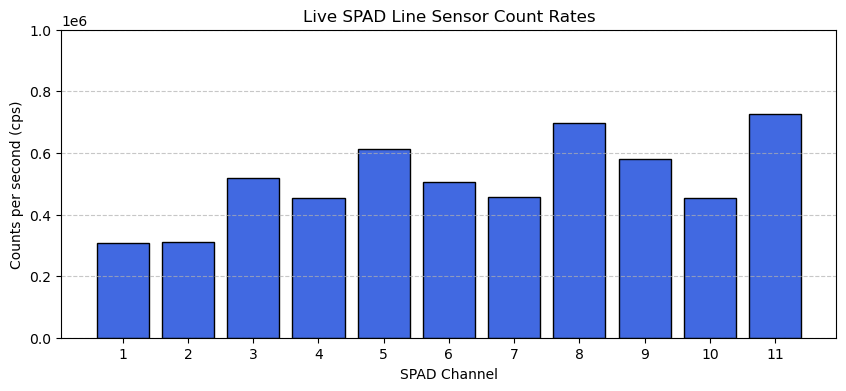

In [ ]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output

# --- 1. HARDWARE DEFINITIONS ---
spad_channels = list(range(1, 12))  # Channels 1 through 24
trigger_voltage = 0.5               # SPAD output

# --- 2. INITIALIZE TIME TAGGER ---
try:
    tagger = tt.createTimeTagger()
    print(f"Connected to Time Tagger: {tagger.getSerial()}")
    
    # Apply trigger levels to all 24 channels
    for ch in spad_channels:
        tagger.setTriggerLevel(ch, trigger_voltage)
        
    print("Trigger levels set. Starting live monitor...")
    time.sleep(1)

    # --- 3. LIVE BAR CHART MONITOR ---
    rate_monitor = tt.Countrate(tagger, channels=spad_channels)
    try:
        for _ in range(10):  # Set measurement time 
            rate_monitor.startFor(1000000000, clear = True)
            rate_monitor.waitUntilFinished()
            rates = rate_monitor.getData()
            
            clear_output(wait=True)
            plt.figure(figsize=(10, 4))
            plt.bar(spad_channels, rates, color='royalblue', edgecolor='black')
            plt.title("Live SPAD Line Sensor Count Rates")
            plt.xlabel("SPAD Channel")
            plt.ylim(0,1e6)
            plt.ylabel("Counts per second (cps)")
            plt.xticks(spad_channels)
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.show()
            
    except KeyboardInterrupt:
        print("Live monitor stopped by user.") # Interrupt the kernel manually if you want to stop earlier
        
except Exception as e:
    print(f"Error: {e}")

## Functions
Functions used to: 
* Measure ```tt.Correlation``` between ```target_pais``` for an specified integration time, bin width and number of bins. 
* Save data in ```spad_line_data``` folders. 

In [ ]:
import TimeTagger as tt
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from datetime import datetime

def measure_and_plot_pairs(tagger, target_pairs, integration_time_sec=10, bin_width=10, n_bins=10000):
    """
    Measures the correlation for a list of SPAD pairs simultaneously and plots them.
    
    Parameters:
    - tagger: The active Swabian TimeTagger instance.
    - target_pairs: List of tuples, e.g., [(1, 2), (1, 12), (1, 24)].
    - integration_time_sec: Measurement duration in seconds.
    - bin_width: Histogram bin width in ps.
    - n_bins: Total number of bins. (10,000 bins * 10ps = +/- 50 ns window)
    """
    # Ensure hardware clock time is an integer in picoseconds
    integration_time_ps = int(integration_time_sec * 1e12)
    
    correlation_objects = {}
    measurement_results = {}
    
    print(f"Starting parallel measurement for {len(target_pairs)} pairs...")
    print(f"Integration time: {integration_time_sec} seconds. Hardware clock running...")

    try:
        # --- 1. INITIALIZE AND START ALL MEASUREMENTS ---
        for pair in target_pairs:
            ch_A, ch_B = pair
            corr = tt.Correlation(tagger, ch_A, ch_B, binwidth=bin_width, n_bins=n_bins)
            correlation_objects[pair] = corr
            
            # Start hardware clock asynchronously
            corr.startFor(integration_time_ps, clear=True)

        # --- 2. WAIT AND EXTRACT DATA ---
        for pair, corr in correlation_objects.items():
            # Synchronize Python script with hardware completion
            corr.waitUntilFinished()
            
            hist = corr.getData()
            t_axis = corr.getIndex()
            
            measurement_results[pair] = {
                'time': t_axis,
                'histogram': hist
            }
            
        print("Data extracted. Generating plots...")

        # --- 3. DYNAMIC PLOTTING ---
        num_plots = len(target_pairs)
        if num_plots == 0:
            print("No pairs provided.")
            return measurement_results

        # Create a clean grid (max 3 columns wide)
        cols = min(3, num_plots)
        rows = math.ceil(num_plots / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
        axes = np.atleast_1d(axes).flatten()

        for idx, pair in enumerate(target_pairs):
            ax = axes[idx]
            ch_A, ch_B = pair
            t_axis = measurement_results[pair]['time']
            hist = measurement_results[pair]['histogram']
            
            # Smart formatting based on the pair relationship
            if ch_A == ch_B:
                color = 'teal'
                title = f"Auto-correlation ({ch_A})"
                # Mask out the delta spike at tau=0 for autocorrelations only
                #mask = (t_axis > 1000) | (t_axis < -1000)
                #t_plot, hist_plot = t_axis[mask], hist[mask]
                t_plot, hist_plot = t_axis, hist
            elif abs(ch_A - ch_B) == 1:
                color = 'firebrick'
                title = f"Neighboring Pixels ({ch_A}, {ch_B})"
                t_plot, hist_plot = t_axis, hist
            else:
                color = 'navy'
                title = f"Distant Pixels ({ch_A}, {ch_B})"
                t_plot, hist_plot = t_axis, hist
            
            # Find the baseline by averaging the tail end of the histogram (last 10%)
            tail_length = int(len(hist_plot) * 0.1)
            baseline_avg = np.mean(hist_plot[-tail_length:])
            y_min = baseline_avg * 0.90
            y_max = baseline_avg * 1.50

            ax.plot(t_plot, hist_plot, color=color, linewidth=1.5, label=f'Pair {ch_A}-{ch_B}')
            ax.set_ylim([y_min, y_max])
            #ax.set_yscale('log')
            ax.set_title(title)
            ax.set_xlabel("Delay $\\tau$ (ps)")
            ax.set_ylabel("Coincidences")
            ax.grid(True, alpha=0.3)
            ax.legend()
            
        # Hide any unused subplots
        for i in range(num_plots, len(axes)):
            axes[i].set_visible(False)
            
        plt.tight_layout()
        plt.show()
        
        return measurement_results

    except Exception as e:
        print(f"An error occurred during measurement: {e}")
        return None

def save_measurement_run(results, run_label="diffuser_run", data_folder):
    """
    Saves the correlation measurement dictionary to compressed Numpy files.
    Appends a precise timestamp to prevent overwriting previous runs.
    """
    # Create the folder if it doesn't exist
    if not os.path.exists(data_folder):
        os.makedirs(data_folder)
        
    # Generate a timestamp (e.g., 20260611_194530)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    print(f"Saving {len(results)} measurement pairs...")
    
    saved_files = []
    for pair, data in results.items():
        ch_A, ch_B = pair
        
        # Format: g2_[ChA]_[ChB]_[Label]_[Timestamp].npz
        filename = f"{data_folder}/g2_{ch_A}_{ch_B}_{run_label}_{timestamp}.npz"
        
        # Save arrays and metadata together
        np.savez_compressed(filename, 
                            time=data['time'], 
                            histogram=data['histogram'], 
                            ch_A=ch_A, 
                            ch_B=ch_B)
        
        saved_files.append(filename)
        print(f"  -> Saved: {filename}")
        
    print(f"Run saved successfully in '{data_folder}/'")
    return timestamp # Return timestamp in case you want to use it for logging

## Decorrelation Measurement
Create tagger object instance, define tuples of pixels to measure, and measure with ``measure_and_plot_pairs``. 

In [ ]:
# Create Time Tagger
tagger = tt.createTimeTagger()

# Define the payload: Compare pixel 12 against distant pixels
payload = [
    ( 1, 1 ),
    ( 2, 2 ),
    ( 3, 3 ),
    ( 4, 4 ),
    ( 5, 5 ),
    ( 6, 6 ),
    ( 7, 7 ),
    ( 8, 8 ),
    ( 9, 9 ),
    ( 10, 10 ),
    ( 11, 11 ),
    ( 1, 2 ),  # Nearest neighbor (Expect thermal bunching peak at tau=0) 
    ( 1, 7 ),
    ( 1, 11 )   # Farthest (Completely flat baseline)
]

# Run the function
results = measure_and_plot_pairs(tagger, 
                                 target_pairs= payload, 
                                 integration_time_sec=5, 
                                 bin_width=2000000, 
                                 n_bins=6000)


In [ ]:

# Save the data immediately 
run_time = save_measurement_run(results, run_label="complete-785nm-CW-diff20degsec", data_folder="../data/raw/decorrrelation_11ch/spad_line_data_run12")

Saving 14 measurement pairs...
  -> Saved: spad_line_data/g2_1_1_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_2_2_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_3_3_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_4_4_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_5_5_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_6_6_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_7_7_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_8_8_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_9_9_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_10_10_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_11_11_complete-785nm-CW-diff15degsec_20260619_164430.npz
  -> Saved: spad_line_data/g2_

# DATA ANALYSIS

## Saved Data Summary 
This block loads a Numpy archive (.npz) from saved measurement runs, extracts the time axis (t_axis) and coincidence counts (hist) to visualize the lineshape.

Additionally, it extracts the original measurement parameters: ```bin_width``` and ```n_bins```. 

### SPAD Correlation Measurement Log

| Run Name / File Prefix | `bin_width` | `n_bins` | Total Time Window | Setup Notes / Description |
| :--- | :--- | :--- | :--- | :--- |
| `spad_line_data_run1` | 10 ps  | 15,000 | -75,000 ps (-0.075 us) to 74,990 ps (0.075 us) | Pulsed laser, g2 correlations |
| `spad_line_data_run2` |  10 ps | 15,000 | -75,000 ps (-0.075 us) to 74,990 ps (0.075 us) | Pulsed laser, g2 correlations |
| `spad_line_data_run3` |  10 ps | 15,000 | -75,000 ps (-0.075 us) to 74,990 ps (0.075 us) | CW laser with rotating diffuser (20/s), g2 correlations |
| `spad_line_data_run4` | 10 ps  | 15,000 | -75,000 ps (-0.075 us) to 74,990 ps (0.075 us) | CW laser with rotating diffuser (20/s), g2 correlations|
| `spad_line_data_run5` |1,000,000ps | 6,000 | -3,000,000,000 ps to 2,999,000,000 ps ($\pm3000 \mu s$) |  CW laser with rotating diffuser (20/s) and int_t_sec=5 |
| `spad_line_data_run6` |2,000,000ps | 6,000 | -6,000 us to 6,000 us | CW laser with rotating diffuser (20 deg/s). Countrate: 100kcps|
| `spad_line_data_run7` |2,000,000ps | 6,000 | -6,000 us to 6,000 us | CW laser with rotating diffuser ( 0 deg/s). Countrate: 100kcps|
| `spad_line_data_run8` |2,000,000ps | 6,000 | -6,000 us to 6,000 us  | CW and rotating diffuser at: 15,10,5,20,0 deg/s at 100kcps|
| `spad_line_data_run9` |2,000,000ps | 6,000 | -6,000 us to 6,000 us  | CW and rotating diffuser at: 0,20,15,10,5 deg/s at 10kcps|
| `spad_line_data_run10`|2,000,000ps | 6,000 | -6,000 us to 6,000 us  | CW and rotating diffuser at: 0,20,15,10,5 deg/s at 50kcps|
| `spad_line_data_run11`|2,000,000ps | 6,000 | -6,000 us to 6,000 us  | CW and rotating diffuser at: 5,10,15,0 deg/s at 200kcps|

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import curve_fit

## Import Single Pixel Measurement Data 

Loading file: ../data/raw/decorrelation_11ch/spad_line_data_run8\g2_10_10_complete-785nm-CW-diff10degsec_20260619_154223.npz
--- Reconstructed Measurement Parameters ---
Bin Width: 2,000,000 ps
Total Bins (n_bins): 6,000
Total Time Window: -6,000,000,000 ps (= -6,000.000 us) to 5,998,000,000 ps (= 5,998.000 us)


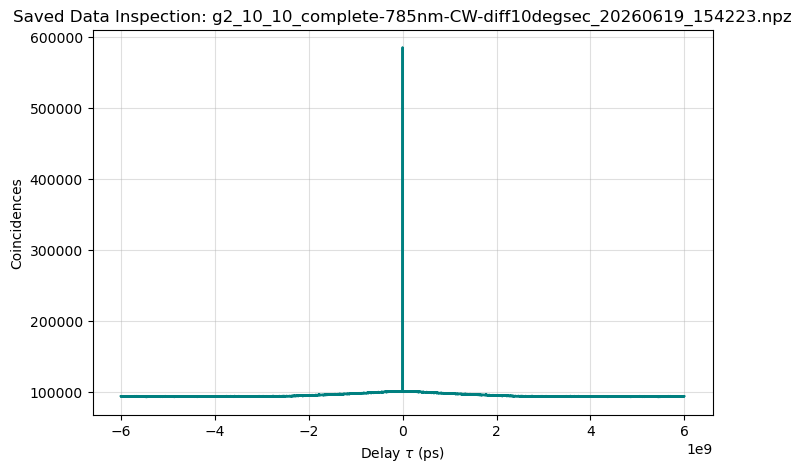

In [29]:
# Select Data to visualize 
folder_path = "../data/raw/decorrelation_11ch/spad_line_data_run8" # Folder Path
files = os.listdir(folder_path)
file_no = files[1] # File within folder

file_path = os.path.join(folder_path, file_no)
print(f"Loading file: {file_path}")

# Load and extract the data
data = np.load(file_path)
t_axis = data['time']
hist = data['histogram']

# Parameter Extraction
bin_width_ps = t_axis[1] - t_axis[0] # bin_width
n_bins_total = len(t_axis) # n_bins
print(f"--- Reconstructed Measurement Parameters ---")
print(f"Bin Width: {bin_width_ps:,.0f} ps")
print(f"Total Bins (n_bins): {n_bins_total:,}")
print(f"Total Time Window: {t_axis[0]:,.0f} ps (= {t_axis[0]/1000000:,.3f} us) to {t_axis[-1]:,.0f} ps (= {t_axis[-1]/1000000:,.3f} us)")

# Plot the measurement
plt.figure(figsize=(8, 5))
plt.plot(t_axis, hist, color='teal', linewidth=1.5)
plt.title(f"Saved Data Inspection: {file_no}")
plt.xlabel("Delay $\\tau$ (ps)")
plt.ylabel("Coincidences")
#plt.ylim([90000,110000])
#plt.xlim([0,10_000_000])
#plt.xscale("log")
plt.grid(True, alpha=0.4)
plt.show()


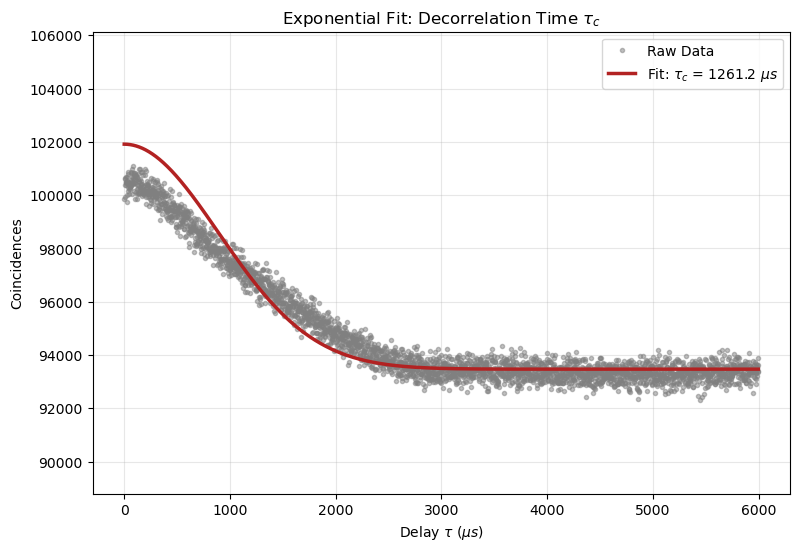

--- Fit Results ---
Decorrelation Time (tau_c): 1261.20 µs
Coherence Factor (beta):    0.0903
Calculated Baseline:        93,470 counts


In [31]:
# Filter data
positive_mask = t_axis >= 0
t_axis = t_axis[positive_mask]
hist = hist[positive_mask]
t_us = t_axis / 1_000_000  # Convert from ps to  micro s. 

# Define exponential function 
def g2_model(tau, baseline, beta, tau_c):
    #return baseline * (1 + beta * np.exp(-2 * tau / tau_c)) # Original
    return baseline * (1 + beta * np.exp(- tau**2 / tau_c**2))

# Parameter estimation 
# The algorithm needs a starting point to find the mathematical minimum
baseline_guess = np.mean(hist[-int(len(hist)*0.01):]) # Average of the last 1% of the tail
peak_guess = np.max(hist[2:1000])                      # Max value near tau=0 without counting the first indices to ignore central peak. 
beta_guess = (peak_guess - baseline_guess) / baseline_guess

# Guess tau_c as the point where the signal drops to roughly 37% (1/e) of its peak amplitude
amplitude = peak_guess - baseline_guess
threshold = baseline_guess + (amplitude * np.exp(-1))
# Find the first index where the histogram drops below the threshold
try:
    tau_c_guess_idx = np.where(hist < threshold)[0][0]
    tau_c_guess = t_us[tau_c_guess_idx]
except IndexError:
    tau_c_guess = 100.0 # Fallback guess if the curve is too noisy

initial_guesses = [baseline_guess, beta_guess, tau_c_guess]

# Fit curve to data 
try:
    # popt contains the optimized parameters: [baseline, beta, tau_c]
    popt, pcov = curve_fit(g2_model, t_us, hist, p0=initial_guesses)
    
    fit_baseline, fit_beta, fit_tau_c = popt
    
    # Generate a smooth line for plotting
    fit_curve = g2_model(t_us, fit_baseline, fit_beta, fit_tau_c)
    
    # Plot
    plt.figure(figsize=(9, 6))
    plt.plot(t_us, hist, '.', color='gray', alpha=0.5, label="Raw Data") # Experimental data
    plt.plot(t_us, fit_curve, color='firebrick', linewidth=2.5, label=f"Fit: $\\tau_c$ = {fit_tau_c:.1f} $\\mu s$") # Fit
    
    # Formatting
    plt.title(f"Exponential Fit: Decorrelation Time $\\tau_c$")
    plt.xlabel("Delay $\\tau$ ($\\mu s$)")
    plt.ylabel("Coincidences")
    plt.ylim(fit_baseline * 0.95, peak_guess * 1.05) # Smart Y-Limits
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # Print Extracted Parameters
    print(f"--- Fit Results ---")
    print(f"Decorrelation Time (tau_c): {fit_tau_c:.2f} µs")
    print(f"Coherence Factor (beta):    {fit_beta:.4f}")
    print(f"Calculated Baseline:        {fit_baseline:,.0f} counts")

except RuntimeError:
    print("Error: The curve fitting algorithm failed to converge. The data might be too noisy, or the time window is too short.")

## Multi Pixel Averaging & Exp. Fit 

Loading and normalizing data for speed 15 deg/s...
Decorrelation Time (tau_c): 1023.43 ± 1.64 µs


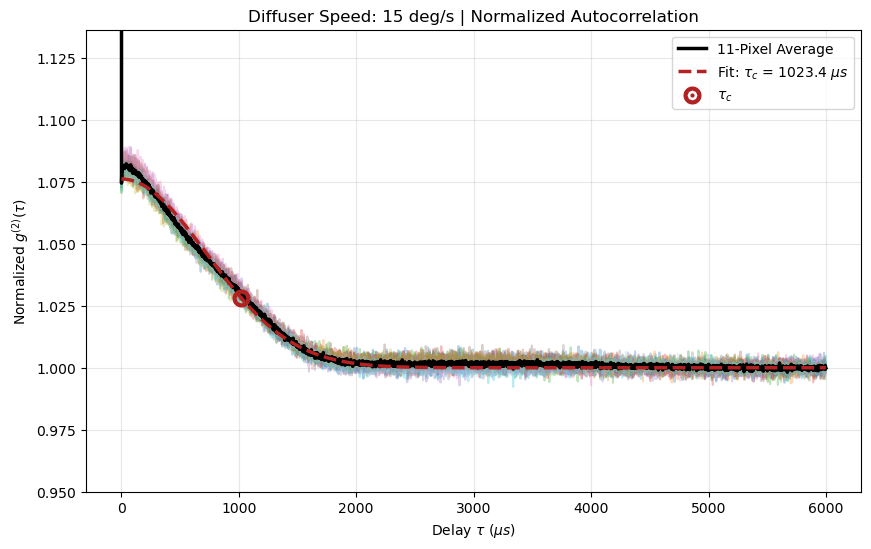

--- Results for 15 deg/s ---
Decorrelation Time (tau_c): 1023.43 µs
Coherence Factor (beta):    0.0762
Standard Deviation (Noise): 0.00052
Signal-to-Noise Ratio:      147.7


In [43]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Select experimental data
folder_path = "../data/raw/decorrelation_11ch/spad_line_data_run11"
target_speed = 15                  # Speed to analyze (0, 5, 10, 15, 20)
run_label = f"complete-785nm-CW-diff{target_speed}degsec"
spad_channels = range(1, 12)        # Pixels 1 through 11

# Load and process data
hist_list = []
t_axis = None

print(f"Loading and normalizing data for speed {target_speed} deg/s...")
for ch in spad_channels:
    # Use '*' as a wildcard for the timestamp
    pattern = f"{folder_path}/g2_{ch}_{ch}_{run_label}_*.npz"
    matched_files = glob.glob(pattern)
    
    if matched_files:
        # Load the first file that matches the pattern
        data = np.load(matched_files[0])
        if t_axis is None:
            t_axis = data['time'] # Store time axis once
            
        raw_hist = data['histogram']
        
        # NORMALIZE: Find the baseline by averaging the last 10% of the tail
        tail_length = int(len(raw_hist) * 0.1)
        baseline = np.mean(raw_hist[-tail_length:])
        
        # Divide by baseline so the curve decays to exactly 1.0
        norm_hist = raw_hist / baseline
        hist_list.append(norm_hist)
    else:
        print(f"  -> Warning: File not found for pair ({ch},{ch})")

# Convert to 2D array and calculate average across all normalized pixels
hist_matrix = np.array(hist_list)
average_hist = np.mean(hist_matrix, axis=0)

# Filter data
# Keep only positive tau and convert to microseconds
positive_mask = t_axis >= 0
t_pos = t_axis[positive_mask] / 1_000_000
hist_pos = average_hist[positive_mask]

# Truncate the hardware spike at tau=0 (drop first 5 bins to be safe)
start_idx = 1
t_fit = t_pos[start_idx:]
hist_fit = hist_pos[start_idx:]

# Fit
# The baseline is strictly 1.0, so it's removed from the fit parameters
def g2_model(tau, beta, tau_c):
    return 1.0 + beta * np.exp(- tau**2 / tau_c**2)

# Initial Guesses
peak_guess = np.max(hist_fit[:50])                      
beta_guess = peak_guess - 1.0 # Beta is just the peak height above 1.0

# Guess tau_c as the point where the signal drops to roughly 37% (1/e) of its peak amplitude
threshold = 1.0 + (beta_guess * np.exp(-1))

try:
    tau_c_guess_idx = np.where(hist_fit < threshold)[0][0]
    tau_c_guess = t_fit[tau_c_guess_idx]
except IndexError:
    tau_c_guess = 100.0 

try:
    # popt contains the optimized parameters: [beta, tau_c]
    popt, pcov = curve_fit(g2_model, t_fit, hist_fit, p0=[beta_guess, tau_c_guess])
    fit_beta, fit_tau_c = popt
    fit_curve = g2_model(t_pos, fit_beta, fit_tau_c)
    #Standard error 
    perr = np.sqrt(np.diag(pcov))
    error_beta = perr[0]
    error_tau_c = perr[1]

    print(f"Decorrelation Time (tau_c): {fit_tau_c:.2f} ± {error_tau_c:.2f} µs")
    
    # Plot
    plt.figure(figsize=(10, 6))
    
    # Plot all 11 individual pixels (faded, using a color map to cycle colors)
    colors = plt.cm.tab20(np.linspace(0, 1, len(hist_matrix)))
    for i, hist in enumerate(hist_matrix):
        plt.plot(t_pos, hist[positive_mask], alpha=0.3, color=colors[i])
        
    # Plot the Average Histogram (Black to stand out)
    plt.plot(t_pos, hist_pos, color='black', linewidth=2.5, label='11-Pixel Average')
    
    # Plot the Fit
    plt.plot(t_pos, fit_curve, color='firebrick', linewidth=2.5, linestyle='--', 
             label=f"Fit: $\\tau_c$ = {fit_tau_c:.1f} $\\mu s$")
    
    # Plot the calculated decorrelation time.
    plt.scatter(fit_tau_c,1+(fit_beta*np.exp(-1)), marker='.', linewidth=10, zorder=5, color='firebrick', label= f"$\\tau_c$")
    plt.title(f"Diffuser Speed: {target_speed} deg/s | Normalized Autocorrelation")
    plt.xlabel("Delay $\\tau$ ($\\mu s$)")
    plt.ylabel("Normalized $g^{(2)}(\\tau)$")
    
    # Zoom Y-Limits around 1.0 and the peak
    #plt.xscale('log')
    plt.ylim(0.95, peak_guess * 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Results & Statistics
    print(f"--- Results for {target_speed} deg/s ---")
    print(f"Decorrelation Time (tau_c): {fit_tau_c:.2f} µs")
    print(f"Coherence Factor (beta):    {fit_beta:.4f}")
    
    # Calculate Signal-to-Noise Ratio (SNR)
    # Noise is the standard deviation of the flat tail (last 10% of the fit data)
    tail_std = np.std(hist_fit[-int(len(hist_fit)*0.1):])
    snr = fit_beta / tail_std
    print(f"Standard Deviation (Noise): {tail_std:.5f}")
    print(f"Signal-to-Noise Ratio:      {snr:.1f}")

except RuntimeError:
    print("Error: Curve fitting failed.")


## Effects of Multi-Pixel Averaging

Loading and normalizing data for speed 20 deg/s...
Running spatial averaging analysis and fitting...


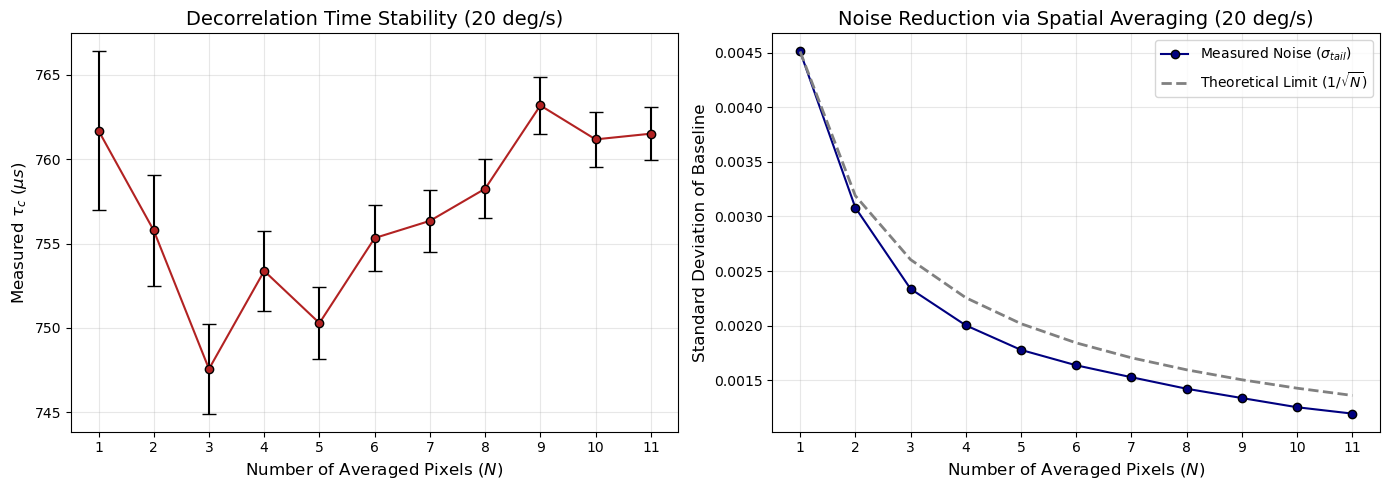

In [38]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load Experimental Data
folder_path = "../data/raw/decorrelation_11ch/spad_line_data_run8" #  kcps folder
target_speed = 20                  # Speed to analyze (0, 5, 10, 15, 20)
run_label = f"complete-785nm-CW-diff{target_speed}degsec"
spad_channels = range(1, 12)        # Pixels 1 through 11

hist_list = []
t_axis = None

print(f"Loading and normalizing data for speed {target_speed} deg/s...")
for ch in spad_channels:
    pattern = f"{folder_path}/g2_{ch}_{ch}_{run_label}_*.npz"
    matched_files = glob.glob(pattern)
    
    if matched_files:
        data = np.load(matched_files[0])
        if t_axis is None:
            t_axis = data['time']
            
        raw_hist = data['histogram']
        tail_length = int(len(raw_hist) * 0.1)
        baseline = np.mean(raw_hist[-tail_length:])
        norm_hist = raw_hist / baseline
        hist_list.append(norm_hist)
    else:
        print(f"  -> Warning: File not found for pair ({ch},{ch})")

hist_matrix = np.array(hist_list)

# Filter
positive_mask = t_axis >= 0
t_pos = t_axis[positive_mask] / 1_000_000
start_idx = 2  # Truncate tau=0 hardware spike

# Averaging 
N_pixels = range(1, len(hist_matrix) + 1)
tau_c_vals = []
tau_c_errors = []
tail_stds = []

def g2_model(tau, beta, tau_c):
    return 1.0 + beta * np.exp(- tau**2 / tau_c**2)

print("Running spatial averaging analysis and fitting...")

for N in N_pixels:
    # Average the first N pixels
    avg_hist = np.mean(hist_matrix[:N], axis=0)
    hist_pos = avg_hist[positive_mask]
    
    # Slice for fitting
    hist_fit = hist_pos[start_idx:]
    t_fit = t_pos[start_idx:]
    
    # Dynamic Guesses
    peak_guess = np.max(hist_fit[:50])
    beta_guess = peak_guess - 1.0
    threshold = 1.0 + (beta_guess * np.exp(-1))
    
    try:
        tau_c_guess_idx = np.where(hist_fit < threshold)[0][0]
        tau_c_guess = t_fit[tau_c_guess_idx]
    except IndexError:
        tau_c_guess = 100.0
        
    # Fit and Extract Error
    try:
        popt, pcov = curve_fit(g2_model, t_fit, hist_fit, p0=[beta_guess, tau_c_guess])
        perr = np.sqrt(np.diag(pcov)) # Extract standard error of parameters
        
        # Calculate standard deviation of the tail
        tail_std = np.std(hist_fit[-int(len(hist_fit)*0.1):])
        
        # Store results
        tau_c_vals.append(popt[1])
        tau_c_errors.append(perr[1]) # Error for tau_c
        tail_stds.append(tail_std)
        
    except RuntimeError:
        print(f"Fit failed for N={N}. Appending NaNs.")
        tau_c_vals.append(np.nan)
        tau_c_errors.append(np.nan)
        tail_stds.append(np.nan)

# 1/N curve
# Calculate a theoretical 1/sqrt(N) curve starting from the N=1 noise level
theoretical_std = tail_stds[0] / np.sqrt(N_pixels)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Decorrelation Time (tau_c) vs Number of Pixels
ax1.errorbar(N_pixels, tau_c_vals, yerr=tau_c_errors, fmt='-o', color='firebrick', 
             ecolor='black', capsize=5, elinewidth=1.5, markeredgecolor='black')
ax1.set_title(f"Decorrelation Time Stability ({target_speed} deg/s)", fontsize=14)
ax1.set_xlabel("Number of Averaged Pixels ($N$)", fontsize=12)
ax1.set_ylabel("Measured $\\tau_c$ ($\\mu s$)", fontsize=12)
ax1.set_xticks(N_pixels)
ax1.grid(True, alpha=0.3)

# Plot 2: Noise (Standard Deviation) vs Number of Pixels
ax2.plot(N_pixels, tail_stds, '-o', color='navy', markeredgecolor='black', label="Measured Noise ($\\sigma_{tail}$)")
ax2.plot(N_pixels, theoretical_std, '--', color='gray', linewidth=2, label="Theoretical Limit ($1/\\sqrt{N}$)")
ax2.set_title(f"Noise Reduction via Spatial Averaging ({target_speed} deg/s)", fontsize=14)
ax2.set_xlabel("Number of Averaged Pixels ($N$)", fontsize=12)
ax2.set_ylabel("Standard Deviation of Baseline", fontsize=12)
ax2.set_xticks(N_pixels)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Decorrelation time measurement as a function of diffuser speed

Starting speed sweep analysis...
  -> 5 deg/s: tau_c = 4661.21 ± 27.76 µs
  -> 10 deg/s: tau_c = 2224.74 ± 13.09 µs
  -> 15 deg/s: tau_c = 1564.40 ± 8.25 µs
  -> 20 deg/s: tau_c = 1147.50 ± 6.50 µs


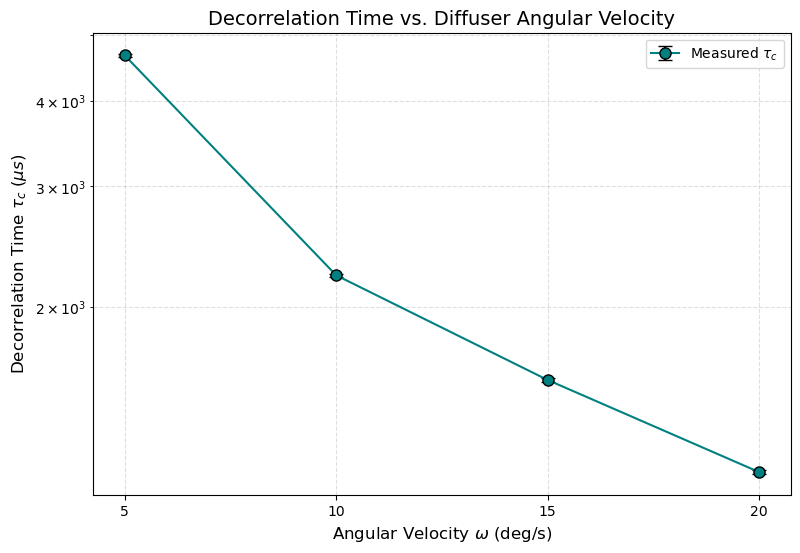

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Load Data
folder_path = "../data/raw/decorrelation_11ch/spad_line_data_run8" # e.g., 100 kcps folder
speeds_to_analyze = [ 5, 10, 15, 20]
spad_channels = range(1, 12)

# Lists to store final extracted data
extracted_speeds = []
extracted_tau_c = []
extracted_tau_c_errors = []

# Exponential curve for fitting
def g2_model(tau, beta, tau_c):
    return 1.0 + beta * np.exp(-2 * tau / tau_c)

print("Starting speed sweep analysis...")

# Iterate over all speeds
for speed in speeds_to_analyze:
    run_label = f"complete-785nm-CW-diff{speed}degsec"
    hist_list = []
    t_axis = None
    
    # Load and normalize all 11 pixels for this specific speed
    for ch in spad_channels:
        pattern = f"{folder_path}/g2_{ch}_{ch}_{run_label}_*.npz"
        matched_files = glob.glob(pattern)
        
        if matched_files:
            data = np.load(matched_files[0])
            if t_axis is None:
                t_axis = data['time']
                
            raw_hist = data['histogram']
            tail_length = int(len(raw_hist) * 0.1)
            baseline = np.mean(raw_hist[-tail_length:])
            
            # Avoid division by zero if baseline is completely flat/zero
            if baseline > 0:
                hist_list.append(raw_hist / baseline)
                
    if not hist_list:
        print(f"  -> Skipping {speed} deg/s: No valid files found.")
        continue

    # Matrix Averaging
    hist_matrix = np.array(hist_list)
    average_hist = np.mean(hist_matrix, axis=0)

    # Prepare Time Axis (Positive only, ignore tau=0 hardware spike)
    positive_mask = t_axis >= 0
    t_pos = t_axis[positive_mask] / 1_000_000
    start_idx = 2 
    
    t_fit = t_pos[start_idx:]
    hist_fit = average_hist[positive_mask][start_idx:]

    # Dynamic Guesses
    peak_guess = np.max(hist_fit[:50])
    beta_guess = peak_guess - 1.0
    threshold = 1.0 + (beta_guess * np.exp(-1))
    
    try:
        tau_c_guess_idx = np.where(hist_fit < threshold)[0][0]
        tau_c_guess = t_fit[tau_c_guess_idx]
    except IndexError:
        tau_c_guess = 100.0 # Fallback for extremely slow or 0 deg/s runs

    # Execute Fit
    try:
        popt, pcov = curve_fit(g2_model, t_fit, hist_fit, p0=[beta_guess, tau_c_guess])
        perr = np.sqrt(np.diag(pcov))
        
        # Only store physically meaningful tau_c values (ignore massive false fits from 0 deg/s)
        if popt[1] < t_pos[-1] * 10: 
            extracted_speeds.append(speed)
            extracted_tau_c.append(popt[1])
            extracted_tau_c_errors.append(perr[1])
            print(f"  -> {speed} deg/s: tau_c = {popt[1]:.2f} ± {perr[1]:.2f} µs")
        else:
            print(f"  -> {speed} deg/s: Curve did not decorrelate within time window.")
            
    except RuntimeError:
        print(f"  -> {speed} deg/s: Curve fitting failed to converge.")

# Plot
plt.figure(figsize=(9, 6))

# Plot the extracted data points with their standard error bars
plt.errorbar(extracted_speeds, extracted_tau_c, yerr=extracted_tau_c_errors, 
             fmt='-o', color='teal', ecolor='black', capsize=5, elinewidth=1.5, 
             markersize=8, markeredgecolor='black', label="Measured $\\tau_c$")

# Formatting
plt.title("Decorrelation Time vs. Diffuser Angular Velocity", fontsize=14)
plt.xlabel("Angular Velocity $\\omega$ (deg/s)", fontsize=12)
plt.ylabel("Decorrelation Time $\\tau_c$ ($\\mu s$)", fontsize=12)

# Ensure the x-axis only shows the discrete speeds you actually measured
plt.xticks(speeds_to_analyze)

# Use a logarithmic scale for the y-axis because tau_c scales with 1/v
if len(extracted_tau_c) > 0:
    plt.yscale('log')

plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.show()

# Theory

## Massively Parallel, real-time multispeckle DCS (500 X 500)
In DCS, coherent light is coupled into a scattering medium and the resulting speckle pattern is collected using a photon counting detector. 
The average speckle decorrelation time $\tau_c$ is estimated by fitting a model to a temporal autocorrelation curve. The ballistic model is suitable for a random flow motion.

Implementation:
* Long coherence length 785 nm (DBR 785 P)
* Max full sensor frame rate is 92.2 kfps == Min exposure time $T_{EX}=10.81 \mu s$
* Data is collected during $T_{INT}$ ($2^16$ exposures) ($50ms$ ). 
* 16 bins. 


## Decoherence Process

### Speckles
The SPAD is like a tiny, fixed keyhole. The 785nm CW laser shining through the rotating diffuser creates a massive, continuous "wall" of thousands of bright and dark speckles. As the diffuser rotates, this entire wall slides across the face of the SPAD.

When one bright speckle slides off the SPAD, **another speckle immediately slides onto it.** The SPAD never stops detecting a heavy stream of photons. The baseline is not "zero light"; the baseline is the constant, random, average background light of the entire shifting pattern.

### Exponential drop
The $g^{(2)}(\tau)$ function does not measure "how much light is left." It measures **predictability (correlation).**

* **The Peak (High Predictability):** At $\tau = 0$, if the SPAD is currently inside a bright speckle, you get a massive spike in coincidences. If you look just a tiny fraction of a microsecond later, that same bright speckle hasn't had time to move very far. The light is still bright. The SPAD successfully "predicts" the immediate future.
* **The Exponential Drop (Losing Memory):** As time passes, that specific bright speckle drifts away. The SPAD is now looking at a completely *new* piece of the speckle pattern. Is the new piece bright? Is it dark? It is a total coin toss.
* **The Baseline (Zero Predictability):** Once enough time has passed that the original speckle is completely gone, the SPAD has totally lost its "memory" of the initial state. You are now just multiplying random light intensities together. The mathematical average of multiplying random fluctuations is a flat, horizontal line—your baseline.

The exponential decay is the exact mathematical visualization of the speckle pattern *losing its correlation to the past*.


### Measuring the Velocity
Once you have your clean exponential curve dropping to the baseline, you fit it with an exponential decay function (e.g., $y = 1 + \beta \exp(-2\tau/\tau_c)$).

### GEMINI 
### Summary of Rotating Diffuser Measurements in BOE 14(2), 703

The paper *“Massive parallel real-time multispeckle diffuse correlation spectroscopy with 250,000 SPADs”* utilizes a rotating ground glass diffuser as a highly controlled dynamic scattering phantom. This setup is used to validate the SPAD array's ability to accurately measure speckle decorrelation times before moving to more complex in-vivo biological tissues.

Here is a breakdown of the experimental parameters, the fitting model, and the underlying optical theory used in this specific portion of the study.

---

### Experimental Parameters

To create a dynamic speckle pattern with a known and controllable decorrelation rate, the researchers utilized the following experimental parameters:

* **Light Source:** A coherent, continuous-wave (CW) laser operating in the near-infrared spectrum.
* **Target Medium:** A ground glass diffuser mounted on a motorized rotation stage.
* **Control Variable:** The angular velocity ($\omega$) of the rotating stage. By varying the motor speed, the linear velocity ($v$) of the microscopic scatterers passing through the stationary laser beam is precisely controlled.
* **Sensor Configuration:** A high-speed, large-format SPAD array (SwissSPAD2) operated at extremely high frame rates to capture the rapid intensity fluctuations of the speckle pattern.
* **Spatial Averaging:** Instead of relying on a single detector, the autocorrelation was computed across thousands of independent pixels (speckles) simultaneously, allowing the signal-to-noise ratio to improve geometrically via spatial averaging rather than long temporal integration.

---

### The Theoretical Framework

In Diffuse Correlation Spectroscopy (DCS), the fundamental goal is to measure the dynamics of scattering particles. In biological tissue, red blood cells undergo pseudo-random Brownian motion, which results in an exponential decay of the electric field autocorrelation function, $g^{(1)}(\tau)$.

However, a rotating diffuser represents a fundamentally different physical system:

1. **Uniform Translation:** The scattering particles on the solid glass disk are not moving randomly; they are undergoing uniform linear translation across the laser beam.
2. **Phase Shift:** As the diffuser translates with velocity $v$, the phase of the scattered light changes linearly over time.
3. **Gaussian Beam Profile:** Because the laser beam illuminating the diffuser has a Gaussian spatial profile (with a beam radius of $w$), the uniform translation of scatterers through this Gaussian profile yields a Gaussian temporal decorrelation.

According to dynamic light scattering theory for a translating random phase screen, the characteristic decorrelation time ($\tau_c$) is determined simply by the time it takes a scatterer to cross the laser beam waist:


$$\tau_c = \frac{w}{v}$$

Since the linear velocity $v$ is proportional to the angular velocity $\omega$ and the radial distance $R$ from the center of rotation ($v = \omega R$), the decorrelation time is strictly inversely proportional to the motor speed:


$$\tau_c \propto \frac{1}{\omega}$$

---

### The Fitting Model

To extract $\tau_c$ from the experimental data, the researchers rely on the **Siegert relation**, which bridges the gap between the unmeasurable electric field autocorrelation $g^{(1)}(\tau)$ and the physically measured intensity autocorrelation $g^{(2)}(\tau)$:


$$g^{(2)}(\tau) = 1 + \beta \vert{}g^{(1)}(\tau)\vert{}^2$$

* $\tau$ is the time delay between photon detection events.
* $\beta$ is the coherence factor, a constant determined by the experimental optics (primarily the ratio of the speckle size to the SPAD pixel active area, as well as polarization effects).

Because the rotating diffuser yields a Gaussian decay for the electric field, substituting the theoretical $g^{(1)}(\tau)$ into the Siegert relation yields the final fitting model used for the diffuser measurements:


$$g^{(2)}(\tau) = 1 + \beta \exp \left( -2 \left( \frac{\tau}{\tau_c} \right)^2 \right)$$

By applying this Gaussian fitting model to the normalized raw data from the SPAD array, the researchers extract $\tau_c$ and plot it against the inverse of the motor speed, yielding a perfectly linear relationship that validates the array's performance.

---
Here are the answers to your questions regarding the paper's methodology, the ballistic fitting model, and the physical derivations of the optical parameters.

### 1. Autocorrelation and Spatial Averaging

Yes, the paper utilizes the exact same signal processing architecture that you did. They compute the temporal intensity autocorrelation $g^{(2)}(\tau)$ for each pixel independently. Then, instead of integrating a single pixel for a long time, they spatially average the individual $g^{(2)}(\tau)$ histograms together. This validates your methodology of averaging the 11 pixels of your linear array.

Regarding the pixel pitch: If the speckle size ($10 \mu\text{m}$) is significantly smaller than the pixel pitch ($125 \mu\text{m}$), it means a single pixel is integrating over multiple distinct speckles at the same time. This spatial integration washes out the intensity fluctuations, which drops the coherence factor ($\beta$, the height of the $g^{(2)}$ peak) close to zero. However, while the contrast is heavily reduced, the temporal decorrelation time ($\tau_c$) extracted from the curve remains mathematically accurate.

### 2. The Ballistic Fitting Model vs. $\tau^2$

Your supervisor is completely correct. The term "ballistic model" is simply the physical justification for why the mathematical fit has a $\tau^2$ in the exponent.

In dynamic light scattering, particles generally exhibit two types of motion, which define the shape of the autocorrelation curve:

* **Diffusive Motion (Brownian):** In liquids or biological tissues, scattering particles undergo random walks. The mean squared displacement is linearly proportional to time ($\langle \Delta r^2 \rangle \propto \tau$). This linear relationship yields a standard **exponential** decay curve: $\exp(-\Gamma \tau)$.
* **Ballistic Motion (Directed flow):** A rotating diffuser does not have random particles; it translates solid scatterers uniformly across the laser beam. Because velocity is constant, distance equals velocity multiplied by time ($x = v \tau$). Therefore, the mean squared displacement is proportional to time squared ($\langle \Delta r^2 \rangle \propto \tau^2$).

Because the exponent in the electric field autocorrelation function is determined by the mean squared displacement, a ballistic $\tau^2$ displacement strictly dictates a **Gaussian** decay curve: $\exp(-(\Gamma \tau)^2)$. When your supervisor mentions the ballistic model proportional to $\tau^2$, they are referring to the underlying kinematics that force the fit to be Gaussian rather than exponential.

### 3. Deriving Spot Size ($D$) and Speckle Size ($S$)

You do not have to accept these blindly; both formulas are direct consequences of classical wave optics and can be derived from first principles.

**Spot Size ($D$)**
This formula comes directly from Gaussian beam propagation and Fraunhofer diffraction. When a laser beam passes through a lens, it cannot be focused to an infinitely small point due to the wave nature of light. If a lens with focal length $f$ focuses a beam with an initial diameter $d_{\text{in}}$, the diffraction-limited spot diameter $D$ at the focal plane is:


$$D = \frac{4 \lambda f}{\pi d_{\text{in}}}$$


This is a standard derivation found by Fourier transforming the Gaussian electric field profile at the lens aperture.

**Speckle Size ($S$)**
The formula for the speckle size at the detector can be derived using the intuition of **Young's Double Slit Experiment**:

1. Imagine the illuminated laser spot on the diffuser (which has diameter $D$) as a densely packed collection of point sources.
2. To find the maximum interference bounds, take the two point sources on the absolute extreme edges of this spot. They act like two slits separated by a distance $D$.
3. The light from these two points propagates and interferes at your SPAD detector, which is located at a distance $z$.
4. According to basic interference theory, the spatial distance between interference fringes on a screen is given by $\frac{\lambda z}{D}$.
5. A single speckle is fundamentally just a localized interference maximum (one 3D fringe).

Therefore, the characteristic physical size of a speckle $S$ at the detector plane is:


$$S \approx \frac{\lambda z}{D}$$


*(Note: A rigorous mathematical derivation using the Van Cittert-Zernike theorem for the spatial coherence of an extended circular source yields a prefactor of 1.22, resulting in $S = \frac{1.22 \lambda z}{D}$, but the fundamental first-principle physics is identical).*

## Explaining g(2)
1. The "AND" Rule of Probability (The Multiplication)In classical math, the theoretical autocorrelation function multiplies the intensity of light right now by the intensity of light in the future: $I(t) \times I(t+\tau)$.In basic statistics, if you want to know the probability of Event A AND Event B happening, you multiply their individual probabilities together.Because Intensity is directly tied to the Probability of a photon arriving, the mathematical expression $I(t) \times I(t+\tau)$ is quite literally calculating: "What is the probability of getting a photon right now AND getting another photon $\tau$ seconds from now?"

2. Hardware executes the "AND": Swabian Time Tagger has a list of timestamps. When the hardware calculates the time differences and finds two photons separated by exactly $\Delta t = 10 \ \mu s$, it has found a real-world instance where Event A (photon at $t$) AND Event B (photon at $t+10 \ \mu s$) actually happened. Every time it drops a single count into the $10 \ \mu s$ bin of your histogram, it is tallying a successful "AND" condition. By summing up thousands of these pairs over your integration window, the hardware is physically calculating that probability.

The SPAD is sitting inside a bright speckle. The intensity is high, so it fires a photon click (Event A). Because $\tau$ is short, the speckle hasn't had time to move. The intensity is still high, so it fires another click (Event B). Because (High Prob) $\times$ (High Prob) is a very large number, the hardware finds a massive amount of pairs with this short time delay. The histogram bin shoots up. The system "remembers" the bright state.



## The exponential

The Random Walk of Light: A single photon bounces off dozens of different scattering particles before exiting and hitting your SPAD. The total electric field at the detector is the sum of millions of these random optical paths.

The Phase Drift: As the diffuser rotates, the scattering particles physically move. When a particle moves even a fraction of a nanometer, the path length of the light changes, which shifts the phase of the light wave.

The Central Limit Theorem: Because the light is bouncing off many independent, randomly moving particles, the total accumulated phase shift is the sum of many small, independent random variables. According to statistical mechanics, the loss of correlation due to many random, independent microscopic fluctuations mathematically integrates into an exponential decay.

Brownian Particles lead to $g^{(1)}(\tau) \propto \exp(-\Gamma \tau)$, . The Siegert Relation $g^{(2)}(\tau) = 1 + \beta |g^{(1)}(\tau)|^2$

## Results with 11 Channel 
### Experimental parameters: 
* Diffuser radius ($R$) = 12.5 mm 
* Angular velocity ($w$) = $20\circ/2$ = 0.349 rad/s 
* Linear velocity of diffuser speckle at edge: $v =Rw = 4.36 mm/s$
* Material in diffuser travels $d= v\tau_c = 16.5 \mu m$

According to Michael diffuser is a "ground glass diffuser" characterized by grit size. 

### Results: Run8
* 5 deg/s: tau_c = 4661.21 ± 27.76 µs
* 10 deg/s: tau_c = 2224.74 ± 13.09 µs
* 15 deg/s: tau_c = 1564.40 ± 8.25 µs
* 20 deg/s: tau_c = 1147.50 ± 6.50 µs


## Next step measurements 

* Align the LASER to the SPAD. 
* Calibrate to 100kcps
* Laser Wavelength: 785 nm
* Results in Runs 6,7,8

Next measurements
* 
